In [1]:
import numpy as np
from utils.load_preprocess import load_preprocess
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
X, y = load_preprocess(n_genes)

AUROC: 0.6401060606060608 [CI 0.48484848484848486 - 0.7954545454545454]


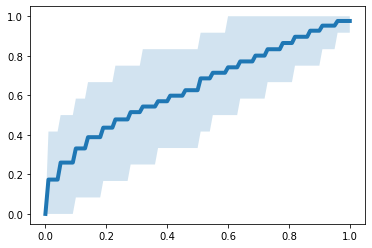

In [3]:
# # times to run bootstrap
n_bootstrap = 1000

# Build an FPR grid to generate TPR on a grid
fpr_grid_vec = np.linspace(0, 1, 101, endpoint=True)
tpr_grid_mat = np.zeros((len(fpr_grid_vec), n_bootstrap))

# Maintain a list of AUROC scores
auroc_list = []

# list of values to try for regularization strength
C_list = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
# list of values to try for l1_ratio
l1_ratio_list = np.linspace(0, 1, 11)
for i in range(n_bootstrap):
    # Split into train, validation, and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                            y,
                                                            stratify=y,
                                                            test_size=0.2,
                                                            random_state=rng.integers(500000))
    X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                    y_train_val,
                                                    stratify=y_train_val,
                                                    test_size=0.2,
                                                    random_state=rng.integers(500000))
    
    # Hyperparameter tuning
    prev_best_auroc = 0.0
    prev_best_test_pred = None
    for C in C_list:
        for l1_ratio in l1_ratio_list:
            # Define model
            model = LogisticRegression(penalty='elasticnet', C=C, l1_ratio=l1_ratio, solver='saga')
            
            # Fit on training data
            model.fit(X_train, y_train)
            
            # Get predictions on validation set
            y_pred = model.predict_proba(X_val)
            
            # Calculate AUROC
            auroc = roc_auc_score(y_val, y_pred[:,1])
            
            # Save if this is the best model
            if auroc > prev_best_auroc:
                # Save the latest best AUROC
                prev_best_auroc = auroc
                # Save the predictions of this model for the test set
                prev_best_test_pred = model.predict_proba(X_test)
                
    fpr, tpr, _ = roc_curve(y_true=y_test, y_score=prev_best_test_pred[:,1])
    fpr = np.concatenate(([0], fpr, [1]))
    tpr = np.concatenate(([0], tpr, [1]))

    interpolator = interp1d(fpr, tpr, kind='nearest')

    tpr_grid_mat[:, i] = interpolator(fpr_grid_vec)

    auroc_list.append(roc_auc_score(y_test, prev_best_test_pred[:,1]))
    
# confidence interval for AUCs
sorted_scores = np.array(auroc_list)
sorted_scores.sort()
auroc_mean = np.mean(sorted_scores)
confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
print('AUROC: {} [CI {} - {}]'.format(auroc_mean, confidence_lower, confidence_upper))

# Plot
# confidence interval for ROC
tpr_grid_mats = np.sort(tpr_grid_mat, axis=1)
tpr_low_05 = tpr_grid_mats[:, int(0.05 * n_bootstrap)]
tpr_top_95 = tpr_grid_mats[:, int(0.95 * n_bootstrap)]
tpr_mean = np.mean(tpr_grid_mat, axis=1)

# plt.hold(True)
ax = plt.gca()  # kwargs.pop('ax', plt.gca())
base_line, = ax.plot(fpr_grid_vec, tpr_mean, '-', linewidth=4)
ax.fill_between(fpr_grid_vec, tpr_low_05, tpr_top_95, facecolor=base_line.get_color(), alpha=0.2);